# 2. Base de datos

## 2.1 Selección de la base de datos

Se trabaja con el registro hidrológico del río Magdalena publicado por el IDEAM en su
portal DHIME. El conjunto reúne las series de caudal medio diario de siete estaciones
escalonadas sobre el cauce, junto con las series de transporte medio diario de sedimentos
de esas mismas estaciones.

La estación objetivo es CALAMAR (código 29037020), situada en el ápice del delta. Dispone
del registro más extenso del conjunto, que abarca de 1940 a 2026, y constituye la
referencia habitual en los estudios de carga sedimentaria de la cuenca. Las seis estaciones
restantes describen el estado del sistema aguas arriba.

## 2.2 Justificación del dataset

El registro de Calamar cubre 86 años de caudal medio diario, extensión que permite un
análisis magnitud-frecuencia estable. Las siete estaciones se distribuyen desde el alto
Magdalena hasta la desembocadura, lo que hace posible seguir la propagación de la onda de
crecida a lo largo del cauce y estimar los tiempos de tránsito entre puntos de medición.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import missingno as msno
import sys

sys.path.insert(0, ".")
from src.config import SEED, DATOS_CRUDOS, DATOS_PROC, ESTACION_OBJETIVO, fijar_semillas, estilo_graficos

fijar_semillas(SEED)
estilo_graficos()

In [2]:
# Los archivos de DHIME traen BOM al inicio y metadatos repetidos en cada fila
META = ["CodigoEstacion", "NombreEstacion", "Variable", "Parametro", "Unidad", "NivelAprobacion"]
ALIAS = {"arrancaplumas  - aut": "arrancaplumas", "puerto salgar - aut": "pto_salgar",
         "el banco - aut": "el_banco"}

def cargar(ruta):
    df = pd.read_csv(ruta, encoding="utf-8-sig", parse_dates=["Fecha"])
    valor = [c for c in df.columns if c not in META + ["Fecha"]][0]
    meta = {c: df[c].iloc[0] for c in META if c in df}
    return df[["Fecha", valor]], valor, meta

def nombrar(meta):
    n = meta["NombreEstacion"].split("[")[0].strip().lower()
    n = ALIAS.get(n, n.replace(" ", "_"))
    return n + ("_transporte" if "transporte" in meta["Parametro"].lower() else "")

series = {}
for ruta in sorted(DATOS_CRUDOS.glob("*.csv")):
    d, valor, meta = cargar(ruta)
    series[nombrar(meta)] = (d, valor, meta)

print(f"{len(series)} series cargadas")

14 series cargadas


In [3]:
# Inventario de lo descargado
inventario = pd.DataFrame([{
    "serie": k,
    "codigo": m["CodigoEstacion"],
    "variable": "transporte" if "transporte" in k else "caudal",
    "unidad": m["Unidad"],
    "desde": d.Fecha.min().date(),
    "hasta": d.Fecha.max().date(),
    "n": len(d),
} for k, (d, v, m) in series.items()]).sort_values(["variable", "desde"])

inventario

,serie,codigo,variable,unidad,desde,hasta,n
0,arrancaplumas,21237020,caudal,m^3/s,1934-01-01,2014-12-31,27855
4,pto_salgar,23037010,caudal,m^3/s,1937-01-01,2026-09-28,28745
1,calamar,29037020,caudal,m^3/s,1940-07-23,2026-09-24,30968
3,el_banco,25027020,caudal,m^3/s,1972-10-01,2026-09-27,19019
5,san_roque,25027320,caudal,m^3/s,1972-10-01,2025-09-13,18751
6,tres_cruces,25027640,caudal,m^3/s,1974-10-01,2026-08-31,16789
2,coyongal,25027930,caudal,m^3/s,1975-03-01,2026-09-04,16409
7,arrancaplumas_transporte,21237020,transporte,KTn/d,1971-01-01,2014-12-31,16013
8,calamar_transporte,29037020,transporte,KTn/d,1972-01-01,2026-09-24,18688
12,san_roque_transporte,25027320,transporte,KTn/d,1972-10-01,2025-09-13,17282


## 2.3 Diccionario de variables

Los archivos de DHIME vienen en formato largo, con los metadatos de la estación repetidos
en cada fila.

| Columna | Tipo | Unidad | Significado | Uso |
|---|---|---|---|---|
| `CodigoEstacion` | identificador | — | código IDEAM de la estación | metadato |
| `NombreEstacion` | categórica | — | nombre de la estación | nombra la serie |
| `Variable` / `Parametro` | categórica | — | tipo de medición | identifica la serie |
| `Fecha` | temporal | día | fecha de la observación | índice temporal |
| `Unidad` | categórica | — | `m^3/s` o `KTn/d` | metadato |
| `Q_MEDIA_D_m3_s` | numérica continua | m³/s | caudal medio diario | variable principal |
| `TR_KT_D_QS_D_kt_dia` | numérica continua | kt/día | transporte medio diario | auditado en 3.1 |
| `NivelAprobacion` | categórica | — | `Preliminar` o `Definitivo` | indicador de calidad |

### Estaciones utilizadas

| Estación | Código | Municipio | Departamento | Lat (N) | Lon (W) | Altitud (m s.n.m.) | Registro |
|---|---|---|---|---:|---:|---:|---|
| ARRANCAPLUMAS - AUT | 21237020 | Guaduas | Cundinamarca | 5,2024 | −74,7276 | 222 | 1934-2014 |
| PUERTO SALGAR - AUT | 23037010 | Puerto Salgar | Cundinamarca | 5,4697 | −74,6622 | 168 | 1937-2026 |
| TRES CRUCES | 25027640 | Achí | Bolívar | 8,7031 | −74,5173 | 31 | 1974-2026 |
| EL BANCO - AUT | 25027020 | El Banco | Magdalena | 8,9925 | −73,9694 | 29 | 1972-2026 |
| SAN ROQUE | 25027320 | El Banco | Magdalena | 9,0716 | −74,1572 | 24 | 1972-2025 |
| COYONGAL | 25027930 | Magangué | Bolívar | 8,9151 | −74,4855 | 20 | 1975-2026 |
| CALAMAR | 29037020 | Calamar | Bolívar | 10,2440 | −74,9147 | 8 | 1940-2026 |

Coordenadas en grados decimales, sistema WGS 84. Fuente: Catálogo Nacional de Estaciones
del IDEAM, consultado el 30 de septiembre de 2026.

El gradiente altitudinal, que va de 222 m s.n.m. en Guaduas a 8 m en Calamar, ordena las
estaciones a lo largo del cauce. El capítulo 3 emplea ese orden para contrastar los tiempos
de tránsito estimados a partir de las series de caudal.

## 2.4 Estructura de los datos

La unidad de observación es el día en la estación Calamar y el nivel de agregación es
diario. Se trata de una serie de tiempo multivariada en la que las estaciones de aguas
arriba actúan como covariables del mismo sistema físico. Las entidades independientes se
reducen a una sola cuenca, de modo que el número de filas sobreestima el tamaño efectivo
de muestra a causa de la autocorrelación temporal que documenta el capítulo 3.

In [4]:
# Tabla ancha sobre el calendario completo de la estacion objetivo.
# Reindexar deja los huecos visibles como NaN.
caudales = {k: v for k, v in series.items() if "transporte" not in k}

tabla = None
for nombre, (d, valor, m) in caudales.items():
    s = d.rename(columns={valor: nombre})
    tabla = s if tabla is None else tabla.merge(s, on="Fecha", how="outer")

obj = caudales[ESTACION_OBJETIVO][0]
calendario = pd.date_range(obj.Fecha.min(), obj.Fecha.max(), freq="D")
df = tabla.set_index("Fecha").reindex(calendario).rename_axis("fecha").reset_index()

ESTACIONES = [c for c in df.columns if c != "fecha"]
print(f"Periodo: {df.fecha.min():%Y-%m-%d} a {df.fecha.max():%Y-%m-%d}")
print(f"Filas: {len(df):,}   Estaciones: {len(ESTACIONES)}")
df.head()

Periodo: 1940-07-23 a 2026-09-24
Filas: 31,475   Estaciones: 7


,fecha,arrancaplumas,calamar,coyongal,el_banco,pto_salgar,san_roque,tres_cruces
0,1940-07-23,961.0,3132.0,NaN,NaN,NaN,NaN,NaN
1,1940-07-24,880.0,3155.0,NaN,NaN,NaN,NaN,NaN
2,1940-07-25,1127.0,3201.0,NaN,NaN,NaN,NaN,NaN
3,1940-07-26,1720.0,3270.0,NaN,NaN,NaN,NaN,NaN
4,1940-07-27,1363.0,3443.0,NaN,NaN,NaN,NaN,NaN


## 2.5 Tamaño de la muestra

In [5]:
n, p = df.shape
print(f"Observaciones (n):  {n:,}")
print(f"Variables (p):      {p}")
print(f"Relación n/p:       {n/p:,.0f}")
print(f"Mínimo de 20.000:   {'cumple' if n >= 20_000 else 'no cumple'}")
print()
print("Entidades independientes: 1 (una sola cuenca).")
print("La autocorrelación temporal reduce el tamaño efectivo de muestra muy por debajo de n.")

Observaciones (n):  31,475
Variables (p):      8
Relación n/p:       3,934
Mínimo de 20.000:   cumple

Entidades independientes: 1 (una sola cuenca).
La autocorrelación temporal reduce el tamaño efectivo de muestra muy por debajo de n.


## 2.6 Calidad de los datos

### 2.6.1 Valores faltantes

| Mecanismo | Significado | Manifestación en datos fluviales |
|---|---|---|
| MCAR | falta completamente al azar | fallas puntuales del instrumento |
| MAR | la falta depende de otras variables observadas | huecos concentrados en ciertas estaciones o épocas |
| MNAR | la falta depende del valor no observado | el sensor se pierde durante la crecida extrema |

Si los huecos se concentraran en aguas altas, el mecanismo sería MNAR y la estimación de la
descarga efectiva quedaría sesgada a la baja, porque faltarían precisamente los caudales
que más sedimento transportan. La hipótesis se contrasta a continuación.

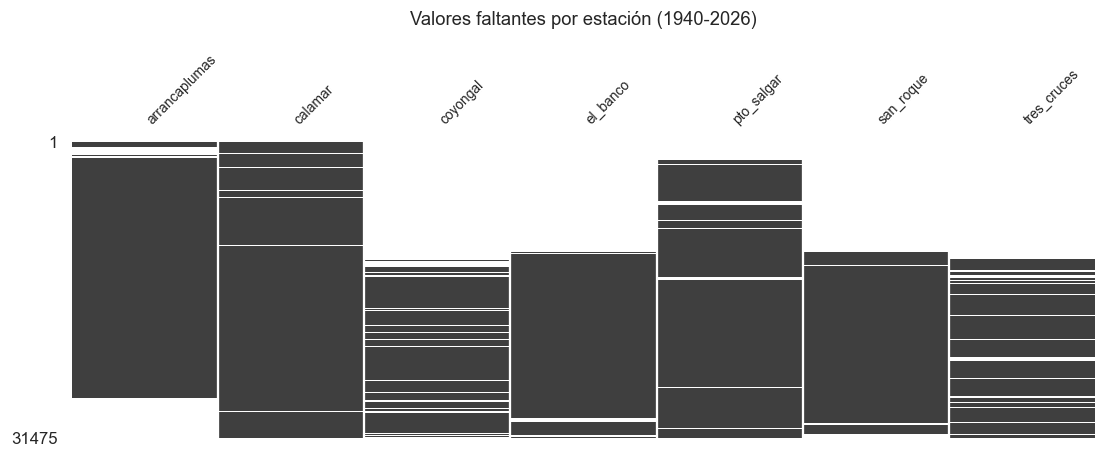

,faltantes,porcentaje,inicio,fin
calamar,507,1.6,1940-07-23,2026-09-24
pto_salgar,3099,9.8,1946-01-01,2026-09-24
arrancaplumas,5771,18.3,1940-07-23,2014-12-31
el_banco,12459,39.6,1972-10-01,2026-09-24
san_roque,12724,40.4,1972-10-01,2025-09-13
tres_cruces,14686,46.7,1974-10-01,2026-08-31
coyongal,15066,47.9,1975-03-01,2026-09-04


In [6]:
fig, ax = plt.subplots(figsize=(12, 3.5))
msno.matrix(df[ESTACIONES], ax=ax, sparkline=False, fontsize=9)
ax.set_title("Valores faltantes por estación (1940-2026)", pad=18)
plt.show()

faltantes = pd.DataFrame({
    "faltantes": df[ESTACIONES].isna().sum(),
    "porcentaje": 100 * df[ESTACIONES].isna().mean(),
    "inicio": [df.loc[df[e].notna(), "fecha"].min().date() for e in ESTACIONES],
    "fin": [df.loc[df[e].notna(), "fecha"].max().date() for e in ESTACIONES],
}).sort_values("porcentaje").round(1)

faltantes

El patrón es estructural: cada estación presenta un bloque sólido de ausencia anterior a su
fecha de instalación, lo que refleja la construcción progresiva de la red de monitoreo.
Calamar y Puerto Salgar cubren desde 1937-1940, mientras que las restantes se incorporan
entre 1972 y 1975. El mecanismo dominante es por tanto MAR, dado que la ausencia depende de
la fecha, una variable observada.

El contraste siguiente verifica si además existe dependencia del propio caudal, lo que
indicaría un componente MNAR.

In [7]:
# Los huecos dentro del periodo operativo de cada estacion,
# se concentran en aguas altas o bajas?
filas = []
for e in ESTACIONES:
    if e == ESTACION_OBJETIVO:
        continue
    ini = df.loc[df[e].notna(), "fecha"].min()
    fin = df.loc[df[e].notna(), "fecha"].max()
    sub = df[(df.fecha >= ini) & (df.fecha <= fin)]
    con = sub.loc[sub[e].notna(), ESTACION_OBJETIVO].dropna()
    sin = sub.loc[sub[e].isna(), ESTACION_OBJETIVO].dropna()
    if len(sin) < 30:
        continue
    u, pv = st.mannwhitneyu(con, sin)
    A = u / (len(con) * len(sin))
    filas.append({"estacion": e, "huecos": len(sin),
                  "Q_con_dato": con.median(), "Q_sin_dato": sin.median(),
                  "p_valor": pv, "efecto_A": A,
                  "lectura": "MNAR" if A < 0.42 else ("MCAR/MAR" if A < 0.58 else "huecos en aguas bajas")})

pd.DataFrame(filas).round(4)

,estacion,huecos,Q_con_dato,Q_sin_dato,p_valor,efecto_A,lectura
0,arrancaplumas,1314,7062.0000,7658.0000,0.0000,0.4669,MCAR/MAR
1,coyongal,2353,7235.0000,6158.0000,0.0000,0.6065,huecos en aguas bajas
2,el_banco,700,7095.0000,7132.4688,0.8807,0.5017,MCAR/MAR
3,pto_salgar,1111,7125.5625,6190.0000,0.0000,0.6181,huecos en aguas bajas
4,san_roque,590,7104.0000,6438.0000,0.0890,0.5205,MCAR/MAR
5,tres_cruces,2167,7106.9687,7141.0000,0.0000,0.5300,MCAR/MAR


### 2.6.2 Duplicados y validación física

En series diarias el duplicado crítico es la fecha repetida. Se aplican además reglas de
validación física: un caudal negativo o nulo resulta imposible en un río de este orden, y
un cambio de varios órdenes de magnitud entre días consecutivos indicaría un error de
unidad en el registro.

In [8]:
print(f"Fechas duplicadas: {df.fecha.duplicated().sum()}")
print(f"Filas duplicadas:  {df.duplicated().sum()}")
print()

validacion = []
for e in ESTACIONES:
    s = df[e]
    razon = (s / s.shift(1)).replace([np.inf, -np.inf], np.nan)
    validacion.append({"estacion": e, "negativos": int((s < 0).sum()), "ceros": int((s == 0).sum()),
                       "min": s.min(), "max": s.max(),
                       "saltos_mayores_3x": int(((razon > 3) | (razon < 1/3)).sum())})

pd.DataFrame(validacion).round(1)

Fechas duplicadas: 0
Filas duplicadas:  0



,estacion,negativos,ceros,min,max,saltos_mayores_3x
0,arrancaplumas,0,0,212.0,7215.0,7
1,calamar,0,0,1520.0,16913.0,0
2,coyongal,0,0,874.8,8648.0,0
3,el_banco,0,0,911.9,9681.0,0
4,pto_salgar,0,0,251.3,6595.3,3
5,san_roque,0,0,7.0,1559.0,0
6,tres_cruces,0,0,14.2,5244.0,1


### 2.6.3 Valores extremos

En hidrología los valores extremos corresponden a las crecidas, que son los eventos de
mayor interés sedimentológico. Recortarlos mediante el rango intercuartílico eliminaría el
objeto de estudio. El criterio aplicado distingue el extremo físicamente plausible del
error de medición, y se apoya en la validación física anterior y en la distancia de
Mahalanobis multivariada que desarrolla el capítulo 3 (Rousseeuw y Van Driessen, 1999).

### 2.6.4 Nivel de aprobación

El IDEAM etiqueta cada dato como preliminar o definitivo. Su distribución condiciona la
confiabilidad del registro.

In [9]:
d_obj, _, _ = series[ESTACION_OBJETIVO]
aprob = pd.read_csv(sorted(DATOS_CRUDOS.glob("*CALAMAR*Q_MEDIA*.csv"))[0],
                    encoding="utf-8-sig", parse_dates=["Fecha"])[["Fecha", "NivelAprobacion"]]

print(aprob.NivelAprobacion.value_counts(normalize=True).round(4).to_string())
print()
print("Proporción por década:")
aprob["decada"] = aprob.Fecha.dt.year // 10 * 10
print(pd.crosstab(aprob.decada, aprob.NivelAprobacion, normalize="index").round(3).to_string())

NivelAprobacion
Preliminar    0.8957
Definitivo    0.1043

Proporción por década:
NivelAprobacion  Definitivo  Preliminar
decada                                 
1940                  0.000       1.000
1950                  0.000       1.000
1960                  0.000       1.000
1970                  0.000       1.000
1980                  0.000       1.000
1990                  0.000       1.000
2000                  0.000       1.000
2010                  0.391       0.609
2020                  0.745       0.255


La etiqueta depende de la época y no del dato. Todo el registro anterior a 2010 figura como
preliminar, y la proporción de datos definitivos alcanza alrededor del 75 % en la década de
2020, lo que refleja que el IDEAM formalizó su proceso de validación recientemente.

Se utiliza el registro completo. Restringirlo a los datos definitivos dejaría alrededor de
3.200 observaciones y descartaría setenta años de información. La decisión se declara entre
las limitaciones del capítulo 5.

### 2.6.5 Sesgos de muestreo y representatividad

La red carece de cobertura espacial uniforme y se densificó a partir de los años setenta,
de modo que el periodo 1940-1972 está representado únicamente por Calamar y Puerto Salgar.
Las estaciones se ubican en sitios accesibles y de interés operativo, principalmente
puertos y poblaciones, siguiendo criterios logísticos antes que un diseño estadístico. El
sufijo AUT en el nombre de algunas estaciones indica automatización en algún momento del
registro, circunstancia que puede introducir discontinuidades instrumentales.

## 2.7 Consideraciones éticas

Los datos son ambientales y agregados, de modo que no contienen información personal ni
admiten reidentificación.

Un modelo mal calibrado que subestime la frecuencia de transporte dominante podría llevar a
subdimensionar obras de protección en comunidades ribereñas, por lo que sus resultados
requieren contraste antes de emplearse en decisiones de ordenamiento territorial.

Sobre la licencia, el portal DHIME autoriza la descarga para uso personal y no comercial
pero reserva cualquier otro derecho. Este trabajo publica el procedimiento de descarga en
lugar de los archivos originales, lo que preserva la reproducibilidad sin incurrir en
republicación no autorizada.

## 2.8 Fuente y licencia

| | |
|---|---|
| Entidad | IDEAM, Instituto de Hidrología, Meteorología y Estudios Ambientales |
| Portal | http://dhime.ideam.gov.co |
| Fecha de descarga | 29 de septiembre de 2026 |
| Licencia | universal, no exclusiva, de libre uso y revocable |

### Términos de uso, transcripción literal del portal DHIME

> **Licencia de uso:** El Ideam le concede una licencia universal, no exclusiva, de libre
> uso y revocable en cualquier momento para:
>
> a. Visualizar este sitio web y todo el material publicado en él mediante el uso de un
>    ordenador o dispositivo móvil a través de un navegador web.
> b. Copiar y almacenar una copia de este sitio web o de todo el material publicado en él,
>    en la memoria caché de su navegador web.
> c. Imprimir las páginas a través de un dispositivo físico (impresora-papel) o dispositivo
>    virtual (impresora-pdf); siempre y cuando sea única y exclusivamente, para su uso
>    personal y privado, que no tenga como fin un uso comercial.
> d. Realizar la descarga de los datos hidrometeorológicos que reposan en la base de datos
>    del Ideam, para su uso personal y privado, que no tenga como fin un uso comercial.
>
> Cualquier otro derecho sobre este sitio o el material publicado en él **NO ESTÁ
> AUTORIZADO**, lo que significa que todos los derechos quedan reservados.

El literal (d) cubre la descarga para uso personal, privado y no comercial, condiciones que
este trabajo cumple. La cláusula final reserva los demás derechos, entre ellos la
redistribución, por lo que los archivos originales quedan fuera del repositorio público. El
procedimiento exacto de descarga se documenta en `DESCARGA_DATOS.md` (IDEAM, 2026).

In [10]:
# El capitulo 3 parte de esta tabla
DATOS_PROC.mkdir(parents=True, exist_ok=True)
df.to_csv(DATOS_PROC / "caudales.csv", index=False)
print(f"Guardado: {DATOS_PROC / 'caudales.csv'}  ({len(df):,} filas)")

Guardado: C:\MACHINE_LEARNING\proyecto_magdalena\datos\procesados\caudales.csv  (31,475 filas)
